In [3]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import corner


events = pd.read_csv("events.dat", sep=" ")
events_wide_ETT = pd.read_csv("../wide_ETT/events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [24]:

width_gw = np.zeros(events.shape[0])
width_gw_wide_ett = np.zeros(events_wide_ETT.shape[0])


for src in range(events.shape[0]):

    posterior_gw = np.load(f"./gw_posteriors/source_{src}/posterior_mm.npz")
    lower_gw, median_gw, upper_gw = np.quantile(posterior_gw["lambda_1"], [0.16, 0.5, 0.84])

    width_gw[src] = upper_gw - lower_gw


for src in range(events_wide_ETT.shape[0]):

    posterior_gw = np.load(f"../../eos_inference/narrow_ETT/gw_posteriors/source_{src}/posterior_mm.npz")
    lower_gw, median_gw, upper_gw = np.quantile(posterior_gw["lambda_1"], [0.16, 0.5, 0.84])

    width_gw_wide_ett[src] = upper_gw - lower_gw

(array([8., 7., 6., 2., 1., 1., 0., 0., 0., 1.]),
 array([0.43488465, 1.0395851 , 1.64428554, 2.24898599, 2.85368643,
        3.45838688, 4.06308732, 4.66778777, 5.27248821, 5.87718866,
        6.4818891 ]),
 [<matplotlib.patches.Polygon at 0x7f62ecd5ff90>])

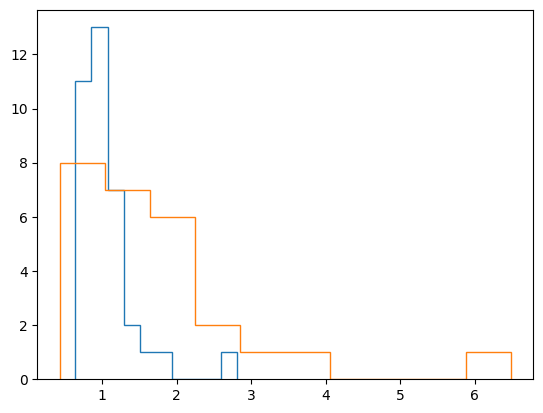

In [22]:
plt.hist(width_gw / events["lambda_2"], histtype="step")
plt.hist(width_gw_wide_ett / events_wide_ETT["lambda_2"], histtype="step")

In [23]:
print((width_gw / events["lambda_2"]).min())
print((width_gw_wide_ett / events_wide_ETT["lambda_2"]).min())

0.6387677094501055
0.4348846546689797


In [25]:
print((width_gw / events["lambda_1"]).min())
print((width_gw_wide_ett / events_wide_ETT["lambda_1"]).min())

0.6033357394439879
0.4598210967248342


In [18]:
events["lambda_1"]

0       62.104051
1      341.457836
2      454.730870
3      326.288632
4       95.009770
5      337.663560
6       25.851976
7       46.197043
8      264.885957
9      247.859371
10      66.361613
11     105.034479
12    1057.511841
13     259.809770
14      28.818705
15     191.781614
16     291.190579
17      30.810818
18     387.217019
19     681.891413
20     189.838625
21     587.641777
22     107.222589
23      41.020461
24      92.097775
25     159.962496
26      92.455165
27     523.004317
28      39.693929
29      50.359118
30     627.442453
31     397.911337
32      42.412475
33     305.207626
34      75.175691
35     361.636064
Name: lambda_1, dtype: float64

In [15]:
events_wide_ETT["snr"].max()

np.float64(104.914)

In [16]:
np.sum(events["snr"]>105)

np.int64(5)

In [17]:
events["snr"].max()

np.float64(229.002)